In [1]:
#LIBRERIAS
%pip install ib_async

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ACERO (HRC) - ACTUALIZACIÓN DE PRECIOS DESDE INTERACTIVE BROKERS
from ib_async import IB, Future
from pathlib import Path
from datetime import datetime, timedelta, date
import pandas as pd
import json, re, os, tempfile
import asyncio

# ========= CONFIG =========
HOST = "127.0.0.1"
PORT = 7496        # 7497 (paper) / 7496 (live)
CLIENT_ID = 17

JSON_PATH = Path(r"C:\Users\DanielAristizabal\Saman\Banca de Inversión - Documents\Super de Alimentos\Gestión de riesgo\Data\data_HRC.json")

# FECHA MÍNIMA - Solo traer datos desde esta fecha
START_DATE = "2025-01-01"

# Rango de años para generar contratos
START_YEAR = 2025  # Año inicial (contratos con datos históricos)
YEARS_AHEAD = 2    # Años hacia adelante desde el año actual
# ==========================

# HRC (Hot-Rolled Coil) - Contratos MENSUALES en NYMEX/COMEX
# Meses estándar CME: F=01, G=02, H=03, J=04, K=05, M=06, N=07, Q=08, U=09, V=10, X=11, Z=12
# NOTA: El código usa 1 solo dígito para el año (ej: HRCG6 = Feb 2026)
MONTH_LETTERS = {
    'F': '01', 'G': '02', 'H': '03', 'J': '04', 'K': '05', 'M': '06',
    'N': '07', 'Q': '08', 'U': '09', 'V': '10', 'X': '11', 'Z': '12'
}
MONTH_NUM_TO_LETTER = {v: k for k, v in MONTH_LETTERS.items()}
ORDERED_MONTHS = ['F', 'G', 'H', 'J', 'K', 'M', 'N', 'Q', 'U', 'V', 'X', 'Z']

# ---------- util contrato ----------
def HRC_code_to_yyyymm(code: str) -> str:
    """Convierte código HRC (ej: HRCF5) a formato YYYYMM (ej: 202501)"""
    m = re.fullmatch(r"HRC([FGHJKMNQUVXZ])(\d)", code.strip().upper())
    if not m:
        raise ValueError(f"Código inválido HRC: {code}")
    letter, y = m.groups()
    y_i = int(y)
    # Determinar década: 0-4 = 2030s, 5-9 = 2020s (asumiendo contexto actual)
    current_decade = (datetime.now().year // 10) * 10
    if y_i >= 5:
        year = current_decade + y_i  # 5->2025, 6->2026, etc.
    else:
        year = current_decade + 10 + y_i  # 0->2030, 1->2031, etc.
    return f"{year}{MONTH_LETTERS[letter]}"

def yyyymm_to_HRC_code(yyyymm: str) -> str:
    """Convierte formato YYYYMM (ej: 202501) a código HRC (ej: HRCF5)"""
    y = int(yyyymm[:4])
    mm = yyyymm[4:6]
    letter = MONTH_NUM_TO_LETTER[mm]
    return f"HRC{letter}{str(y)[-1]}"  # Solo último dígito del año

def generate_HRC_contracts() -> list:
    """Genera lista de contratos HRC desde START_YEAR hasta años adelante"""
    contracts = []
    current_year = datetime.now().year
    end_year = current_year + YEARS_AHEAD
    
    for year in range(START_YEAR, end_year + 1):
        for letter in ORDERED_MONTHS:
            code = f"HRC{letter}{str(year)[-1]}"  # Solo último dígito
            contracts.append(code)
    return contracts

async def qualify_HRC_async(ib: IB, yyyymm: str):
    """Califica contrato HRC en NYMEX/COMEX"""
    for ex in ("NYMEX", "COMEX"):
        fut = Future(
            symbol="HRC",
            lastTradeDateOrContractMonth=yyyymm,
            exchange=ex,
            currency="USD",
            includeExpired=True
        )
        try:
            qs = await ib.qualifyContractsAsync(fut)
            if qs:
                return qs[0]
        except Exception:
            pass
        await asyncio.sleep(0.05)
    return None

# ---------- históricos ----------
async def fetch_history_from_date(ib: IB, q, start_date: str):
    """Descarga histórico desde start_date hasta hoy"""
    start_dt = pd.to_datetime(start_date)
    end_dt = datetime.now()
    days = max(1, (end_dt - start_dt).days + 1)
    
    # Limitar a máximo 365 días para evitar timeouts
    days = min(days, 365)
    
    for what in ("TRADES", "MIDPOINT", "BID_ASK"):
        try:
            bars = await ib.reqHistoricalDataAsync(
                q, endDateTime="", durationStr=f"{days} D",
                barSizeSetting="1 day", whatToShow=what,
                useRTH=True, formatDate=2,
                timeout=30
            )
            if bars:
                rows = []
                for b in bars:
                    d = str(b.date)
                    if d >= start_date:
                        rows.append({
                            "date": d, "open": b.open, "high": b.high, "low": b.low,
                            "close": b.close, "volume": b.volume, "openinterest": None
                        })
                if rows:
                    df = pd.DataFrame(rows).drop_duplicates("date").sort_values("date")
                    return df.to_dict(orient="records")
        except Exception as e:
            pass
        await asyncio.sleep(0.3)
    return []

# ---------- JSON I/O ----------
def load_db(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except:
        return {}

def atomic_save(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    fd, tmp = tempfile.mkstemp(prefix=path.name, dir=str(path.parent))
    try:
        with os.fdopen(fd, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        os.replace(tmp, path)
    except Exception:
        try:
            os.remove(tmp)
        finally:
            raise

# ---------- main async ----------
async def main_async():
    db = load_db(JSON_PATH)
    
    ib = IB()
    try:
        await ib.connectAsync(HOST, PORT, clientId=CLIENT_ID)
    except Exception as e:
        print("No se pudo conectar a IBKR:", e)
        return

    try:
        today = datetime.now()
        
        # Contratos existentes en JSON (patrón HRC + letra mes + 1 dígito año)
        HRC_contracts = [k for k in db.keys() if re.fullmatch(r"HRC[FGHJKMNQUVXZ]\d", k)]
        
        # Si no hay contratos, generar automáticamente
        if not HRC_contracts:
            print("JSON vacío - Generando contratos automáticamente...")
            HRC_contracts = generate_HRC_contracts()
            print(f"   Contratos generados: {len(HRC_contracts)} (desde {START_YEAR})\n")
        
        print(f"Contratos a procesar: {len(HRC_contracts)}")
        print(f"Fecha mínima: {START_DATE}\n")
        
        updated = 0
        skipped = 0
        
        for code in sorted(HRC_contracts, key=lambda x: HRC_code_to_yyyymm(x)):
            try:
                yyyymm = HRC_code_to_yyyymm(code)
            except ValueError:
                continue
            
            q = await qualify_HRC_async(ib, yyyymm)
            if not q:
                print(f"   {code}: no disponible en IBKR")
                skipped += 1
                continue
            
            # Obtener última fecha en JSON
            bars = db.get(code, [])
            bars = [r for r in bars if r["date"] >= START_DATE]
            last_date = max((r["date"] for r in bars), default=None)
            
            if last_date:
                start = (pd.to_datetime(last_date) + timedelta(days=1)).strftime("%Y-%m-%d")
                if start <= today.strftime("%Y-%m-%d"):
                    new_rows = await fetch_history_from_date(ib, q, start)
                    if new_rows:
                        merged = (pd.concat([pd.DataFrame(bars), pd.DataFrame(new_rows)], ignore_index=True)
                                  .drop_duplicates("date").sort_values("date"))
                        db[code] = merged.to_dict(orient="records")
                        print(f"✅ {code}: +{len(new_rows)} filas (hasta {merged.iloc[-1]['date']})")
                        updated += 1
                    else:
                        print(f"   {code}: al día ({last_date})")
                else:
                    print(f"   {code}: al día ({last_date})")
            else:
                rows = await fetch_history_from_date(ib, q, START_DATE)
                if rows:
                    db[code] = rows
                    print(f"✅ {code}: {len(rows)} filas nuevas")
                    updated += 1
                else:
                    print(f"   {code}: sin datos históricos")
            
            await asyncio.sleep(0.5)
        
        atomic_save(JSON_PATH, db)
        
        HRC_with_data = [k for k in db.keys() if re.fullmatch(r"HRC[FGHJKMNQUVXZ]\d", k) and db[k]]
        
        print(f"\n{'='*50}")
        print(f"Actualizados: {updated} | Con datos: {len(HRC_with_data)} | Omitidos: {skipped}")
        print(f"Archivo: {JSON_PATH.name}")
        print(f"{'='*50}")
        
        if HRC_with_data:
            print("\nÚltima fecha por contrato:")
            for code in sorted(HRC_with_data, key=lambda x: HRC_code_to_yyyymm(x)):
                bars = db.get(code, [])
                last = max((r["date"] for r in bars), default="N/A")
                print(f"  {code}: {last}")

    finally:
        if ib.isConnected():
            ib.disconnect()

await main_async()

Error 200, reqId 3: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202501', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202501', exchange='NYMEX', currency='USD', includeExpired=True)


JSON vacío - Generando contratos automáticamente...
   Contratos generados: 48 (desde 2025)

Contratos a procesar: 48
Fecha mínima: 2025-01-01

   HRCF5: no disponible en IBKR


Error 200, reqId 4: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202502', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202502', exchange='NYMEX', currency='USD', includeExpired=True)
Error 200, reqId 5: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202503', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202503', exchange='NYMEX', currency='USD', includeExpired=True)
Error 200, reqId 6: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202504', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202504', exchange='NYMEX', currency='USD', includeExpired=True)


   HRCG5: no disponible en IBKR
   HRCH5: no disponible en IBKR
   HRCJ5: no disponible en IBKR


Error 200, reqId 7: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202505', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202505', exchange='NYMEX', currency='USD', includeExpired=True)
Error 200, reqId 8: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202506', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202506', exchange='NYMEX', currency='USD', includeExpired=True)
Error 200, reqId 9: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202507', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202507', exchange='NYMEX', currency='USD', includeExpired=True)


...

   HRCK8: no disponible en IBKR
   HRCM8: no disponible en IBKR
   HRCN8: no disponible en IBKR


Error 200, reqId 46: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202808', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202808', exchange='NYMEX', currency='USD', includeExpired=True)
Error 200, reqId 47: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202809', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202809', exchange='NYMEX', currency='USD', includeExpired=True)
Error 200, reqId 48: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202810', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202810', exchange='NYMEX', currency='USD', includeExpired=True

   HRCQ8: no disponible en IBKR
   HRCU8: no disponible en IBKR
   HRCV8: no disponible en IBKR


Error 200, reqId 49: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202811', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202811', exchange='NYMEX', currency='USD', includeExpired=True)
Error 200, reqId 50: No se encuentra definici\u00f3n del activo solicitado, contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202812', exchange='NYMEX', currency='USD', includeExpired=True)
Unknown contract: Future(symbol='HRC', lastTradeDateOrContractMonth='202812', exchange='NYMEX', currency='USD', includeExpired=True)


   HRCX8: no disponible en IBKR
   HRCZ8: no disponible en IBKR

Actualizados: 0 | Con datos: 0 | Omitidos: 48
Archivo: data_HRC.json


In [1]:
# PRECIOS DEL ÚLTIMO DÍA DEL MES ANTERIOR - TODOS LOS FUTUROS DE ACERO
from datetime import date
from dateutil.relativedelta import relativedelta
import pandas as pd
import json
from pathlib import Path
import re

JSON_PATH = Path(r"C:\Users\DanielAristizabal\Saman\Banca de Inversión - Documents\Super de Alimentos\Gestión de riesgo\Data\data_HRC.json")

# Cargar datos
with open(JSON_PATH, "r", encoding="utf-8") as f:
    db = json.load(f)

# Calcular mes anterior
hoy = date.today()
primer_dia_mes_actual = hoy.replace(day=1)
ultimo_dia_mes_anterior = primer_dia_mes_actual - relativedelta(days=1)
mes_anterior = ultimo_dia_mes_anterior.strftime("%Y-%m")

print(f"Buscando precios del mes: {mes_anterior}")
print(f"(Último día del mes anterior: {ultimo_dia_mes_anterior})\n")

# Recopilar precios del último día del mes anterior para cada contrato
resultados = []

HRC_contracts = [k for k in db.keys() if re.fullmatch(r"HRC[HKNUZ]\d{2}", k)]

for code in sorted(HRC_contracts):
    bars = db.get(code, [])
    
    # Filtrar solo fechas del mes anterior
    fechas_mes = [r for r in bars if r["date"].startswith(mes_anterior)]
    
    if fechas_mes:
        # Obtener el último día disponible del mes
        ultimo_registro = max(fechas_mes, key=lambda x: x["date"])
        resultados.append({
            "Contrato": code,
            "Fecha": ultimo_registro["date"],
            "Close": ultimo_registro["close"],
            "Volume": ultimo_registro["volume"]
        })
    else:
        resultados.append({
            "Contrato": code,
            "Fecha": "Sin datos",
            "Close": None,
            "Volume": None
        })

# Crear DataFrame
df_ultimo_dia_mes = pd.DataFrame(resultados)
print(f"{'='*60}")
print(f"PRECIOS ÚLTIMO DÍA DEL MES ANTERIOR ({mes_anterior})")
print(f"{'='*60}")
display(df_ultimo_dia_mes)

Buscando precios del mes: 2026-01
(Último día del mes anterior: 2026-01-31)

PRECIOS ÚLTIMO DÍA DEL MES ANTERIOR (2026-01)


""


In [3]:
# VOLATILIDAD DEL ACERO (PRECIOS INVESTING)
import pandas as pd
import numpy as np

# Cargar datos (mismo directorio)
df = pd.read_csv(r"Datos históricos Bobina de acero de EE.UU..csv")

# Limpiar columna de precios (formato europeo: coma como decimal)
df['Precio'] = df['Último'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Convertir fecha (formato DD.MM.YYYY)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')

# Ordenar por fecha ascendente
df = df.sort_values('Fecha').reset_index(drop=True)

# Calcular retornos logarítmicos
df['Retorno_Log'] = np.log(df['Precio'] / df['Precio'].shift(1))

# Calcular volatilidad diaria (desviación estándar de retornos)
volatilidad_diaria = df['Retorno_Log'].std()

# Anualizar (252 días de trading)
volatilidad_anualizada = volatilidad_diaria * np.sqrt(252)

print(f"Volatilidad diaria: {volatilidad_diaria:.4%}")
print(f"Volatilidad anualizada: {volatilidad_anualizada:.2%}")


Volatilidad diaria: 2.0252%
Volatilidad anualizada: 32.15%


Acero HRC - Registros: 787
Rango: 2023-01-03 a 2026-02-05

Volatilidad diaria: 2.0252%
Volatilidad anualizada: 32.15%


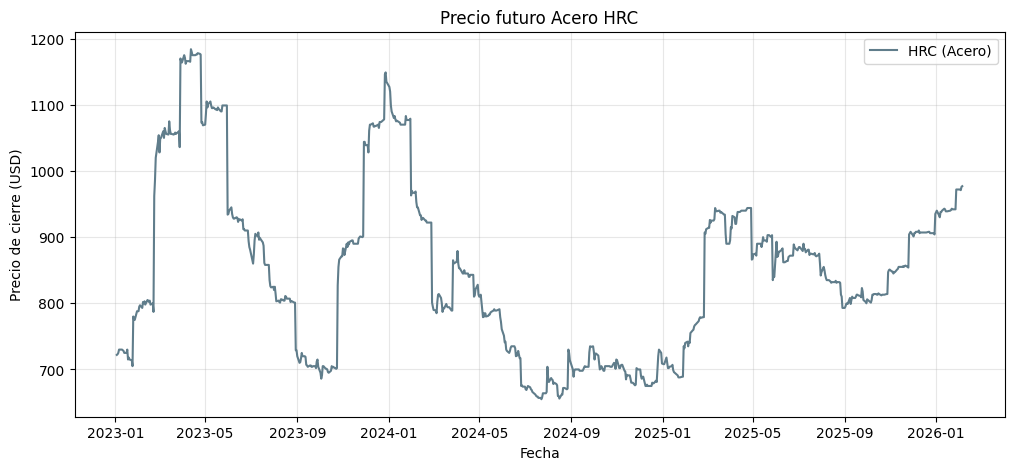

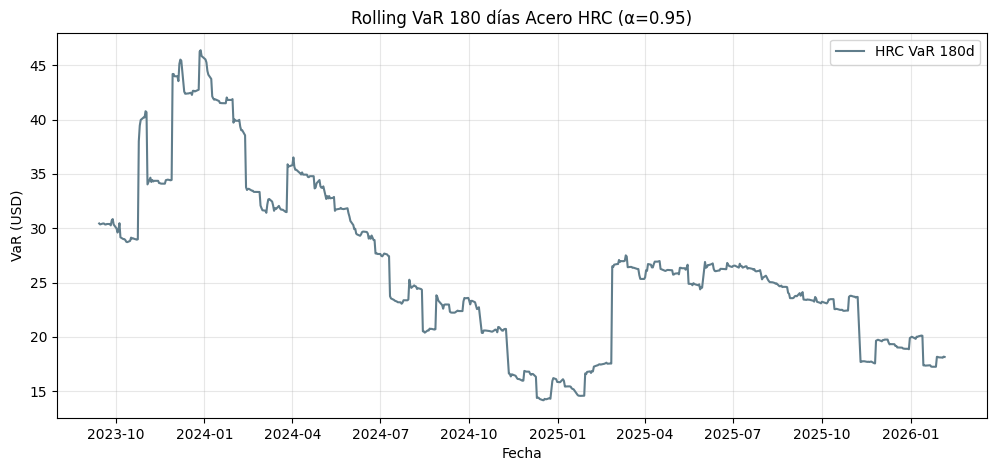

In [4]:
# ROLLING VAR EN USD PARA FUTUROS DE ACERO (HRC)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================== CONFIG ========================
CSV_PATH = r"Datos históricos Bobina de acero de EE.UU..csv"

ROLLING_WINDOW = 180
VAR_ALPHA = 0.95
# =======================================================

def load_acero_csv(csv_path: str) -> pd.Series:
    df = pd.read_csv(csv_path)
    
    # Limpiar columna de precios (formato europeo: coma como decimal)
    df['close'] = df['Último'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
    
    # Convertir fecha (formato DD.MM.YYYY)
    df['date'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')
    
    # Ordenar y crear serie
    s = (df.sort_values('date')
         .drop_duplicates(subset=['date'], keep='last')
         .set_index('date')['close'])
    
    return s

def rolling_var_usd_from_price(price_series: pd.Series, window: int = 180, alpha: float = 0.95) -> pd.Series:
    returns = np.log(price_series / price_series.shift(1)).dropna()
    rolling_var = returns.rolling(window).var()
    z = {0.90: 1.2816, 0.95: 1.6449, 0.975: 1.96, 0.99: 2.3263}.get(alpha, 1.6449)
    var_usd = z * np.sqrt(rolling_var) * price_series.loc[rolling_var.index]
    return var_usd

# --------------------- CARGA DATOS ---------------------
hrc_series = load_acero_csv(CSV_PATH)

print(f"Acero HRC - Registros: {len(hrc_series)}")
print(f"Rango: {hrc_series.index.min().date()} a {hrc_series.index.max().date()}")

# --------------------- VOLATILIDAD ANUALIZADA ---------------------
retornos_log = np.log(hrc_series / hrc_series.shift(1)).dropna()
volatilidad_diaria = retornos_log.std()
volatilidad_anualizada = volatilidad_diaria * np.sqrt(252)

print(f"\nVolatilidad diaria: {volatilidad_diaria:.4%}")
print(f"Volatilidad anualizada: {volatilidad_anualizada:.2%}")

# --------------------- GRAFICA PRECIOS ---------------------
plt.figure(figsize=(12, 5))
plt.plot(hrc_series.index, hrc_series, label='HRC (Acero)', color='#607D8B')
plt.title("Precio futuro Acero HRC")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------------------- ROLLING VAR (USD) ---------------------
hrc_var = rolling_var_usd_from_price(hrc_series, window=ROLLING_WINDOW, alpha=VAR_ALPHA)

plt.figure(figsize=(12, 5))
plt.plot(hrc_var.index, hrc_var, label=f"HRC VaR {ROLLING_WINDOW}d", color='#607D8B')
plt.title(f"Rolling VaR {ROLLING_WINDOW} días Acero HRC (α={VAR_ALPHA})")
plt.xlabel("Fecha")
plt.ylabel("VaR (USD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
